In [2]:
import seaborn as sns

from assembly_designer.workflow.workflow import LiquidHandlingWorkflow
from assembly_designer.manager.manager import AssemblyWorkflowManager
from assembly_designer.mtp_manager.mtp_manager import MTPManager
from assembly_designer.utils import calculate_dreamtaq_mastermix_components
from assembly_designer.utils import find_planning_file

import logging
logging.basicConfig(level=logging.INFO)


In [3]:
# Meta data

type_of_molbiowork="PCR"
try:
    file = find_planning_file(r".", "PCR")
except:
    file = "PCR_Designer.xlsx"

sheet_name="Plan+"

09:47:25 INFO assembly_designer.utils.utils: Found planning file: C:\Users\domin\Documents\Git_Projekte\assembly_designer\examples\01 Liquid Handling\02 Combinational PCR\01 Basic_Example\PCR_Designer.xlsx


In [4]:
# Initialize Workflow

# This cell defines the liquid handling workflow steps for MoClo assembly.
# Each workflow.add_step() call corresponds to a worklist file that will be generated.
#
# KEY PARAMETERS EXPLAINED:
# - sample_handling: "transfer" (move samples to specific wells) or "sample_distribution" (distribute to multiple wells)
# - start: "Yes" (first operation on this plate, initializes volumes) or "No" (subsequent operation)
# - additional_liquid_factor: Multiplier for extra volume (e.g., 1.1 = 10% extra for pipetting safety)
# - fake_source_plate: For simulation when source isn't a real plate


# ADJUST THIS WORKFLOW BASED ON YOUR EXCEL PLANNING FILE
# - Uncomment/comment steps based on parts in your assembly (e.g., if no Signal Peptide, keep it commented)
workflow = LiquidHandlingWorkflow()

workflow.add_step(
    process_label="Worklist_Water",
    source_plate="water",
    destination_plate="mtp_template",
    liquid_handling="transfer Water",
    sample_handling="transfer",
    start = "No",
    additional_liquid_factor = 1.1,
)
workflow.add_step(
    process_label="Worklist_Template",
    source_plate="mtp_template",
    destination_plate="mtp_destination",
    liquid_handling="transfer Template",
    sample_handling="transfer",
    start = "Yes",
    additional_liquid_factor = 1.1,
)
workflow.add_step(
    process_label="Worklist_MM",
    source_plate="mtp_source",
    destination_plate="mtp_destination",
    liquid_handling="Mastermix",
    sample_handling="sample_distribution",
    fake_source_plate="master_mix",
    start = "Yes",
    additional_liquid_factor = 1.6,
)
workflow.add_step(
    process_label="Worklist_Primer1",
    source_plate="mtp_primer_stocks",
    destination_plate="mtp_source",
    liquid_handling="transfer Primer1",
    sample_handling="transfer",
    start = "Yes",
    additional_liquid_factor = 1.1,
)
workflow.add_step(
    process_label="Worklist_Primer2",
    source_plate="mtp_primer_stocks",
    destination_plate="mtp_source",
    liquid_handling="transfer Primer2",
    sample_handling="transfer",
    start = "Yes",
    additional_liquid_factor = 1.1,
)
workflow.add_step(
    process_label="Worklist_PCR_Primer",
    source_plate="mtp_source",
    destination_plate="mtp_destination",
    liquid_handling="Primer Mix",
    sample_handling="sample_distribution",
    fake_source_plate="primer_mix",
    start = "No",
    additional_liquid_factor = 1.6,
)



09:47:25 INFO assembly_designer.workflow.workflow: Added step: Worklist_Water
09:47:25 INFO assembly_designer.workflow.workflow: Added step: Worklist_Template
09:47:25 INFO assembly_designer.workflow.workflow: Added step: Worklist_MM
09:47:25 INFO assembly_designer.workflow.workflow: Added step: Worklist_Primer1
09:47:25 INFO assembly_designer.workflow.workflow: Added step: Worklist_Primer2
09:47:25 INFO assembly_designer.workflow.workflow: Added step: Worklist_PCR_Primer


09:47:25 INFO assembly_designer.workflow.workflow: Flowchart saved to results\workflow.png


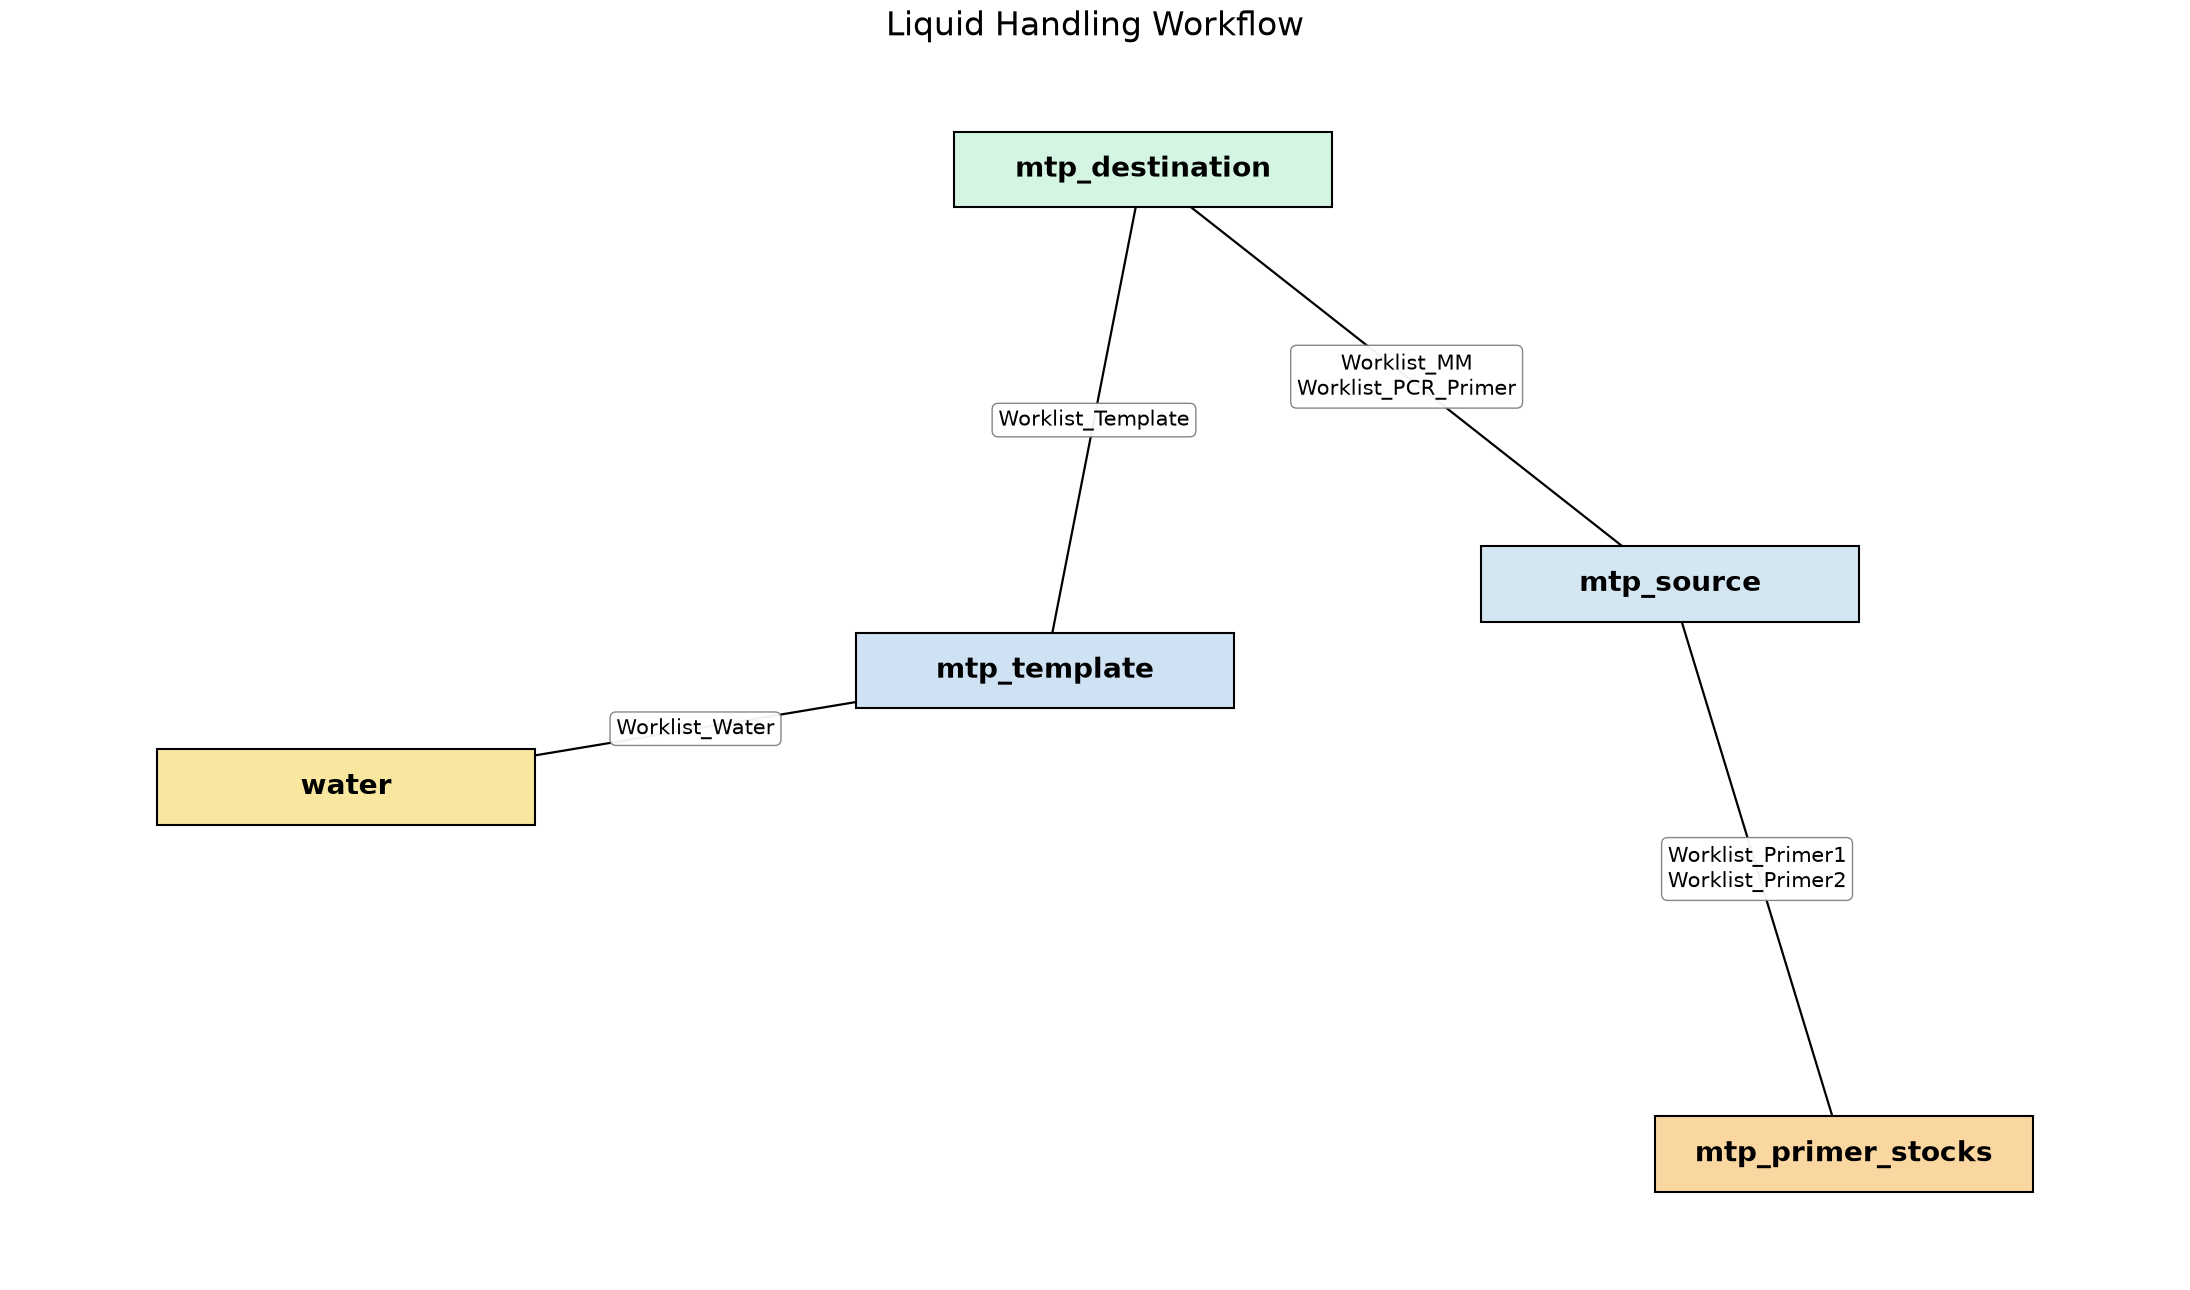

In [5]:
workflow.generate_flowchart(
    save_path="workflow.png",
    export_format="png",
    fig_size=(22.0, 13.0),
    dpi=300,
    font_family="DejaVu Sans",
    node_font_size=20,
    edge_font_size=15,
    title="Liquid Handling Workflow",
    title_font_size=24,
    box_width=4.5,
    box_height=1.8,
    node_facecolor="#CFE2F3",
    node_edgecolor="black",
    node_linewidth=1.5,
    edge_color="black",
    edge_width=1.6,
    arrow_size=22,
    color_by_plate_type=True,
    plate_colors=None,
    label_box_alpha=0.95,
    show_axes=False,
    transparent=False,
    pad_inches=0.4,
    show_plot=True,
    max_labels_per_edge=None,
    spring_k=2.2,
    spring_iterations=400,
    spring_seed=42,
    scale=12.0,
)

In [6]:
# Initialize with Golden Gate template
mtp_manager = MTPManager(default_template=type_of_molbiowork)

# # List MTPs for Golden Gate
# print("PCR template MTPs:", mtp_manager.list_mtps())

# # Access a specific MTP
# mtp = mtp_manager.get_mtp("mtp_source")

# # Switch to PCR template
# mtp_manager.switch_template("Golden Gate")
# print("PCR template MTPs:", mtp_manager.list_mtps())

In [7]:
# Create AssemblyWorkflowManager
assembly_manager = AssemblyWorkflowManager()

In [8]:
# Initialize Workflow Manager
assembly_manager.initialize(plot=False, 
                            plot_information=False,
                            file_path=file,
                            mtp_manager=mtp_manager,
                            workflow=workflow,
                            sheet_name=sheet_name,
                            type_of_molbiowork=type_of_molbiowork)



09:47:25 INFO assembly_designer.manager.manager: Initializing AssemblyWorkflowManager...
C:\Users\domin\Documents\Git_Projekte\assembly_designer\assembly_designer\manager\manager.py:433: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  norm = sheet_df.applymap(lambda x: str(x).strip().lower() if pd.notna(x) else "")
C:\Users\domin\Documents\Git_Projekte\assembly_designer\assembly_designer\manager\manager.py:2571: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(
09:47:26 INFO assembly_designer.manager.manager: All parts matched correctly.
09:47:26 INFO assembly_designer.manager.manager: Found 6 matching sheet(s): ['Worklist_Water', 'Worklist_Template', 'Worklist_MM', 'Worklist_PCR_Primer', 'Worklist_Primer1', 'Worklist_Primer2']
09:47:26 INFO assembly_designer.manager.manager: Found 6 worklist sheet(s): ['Worklist_Water', 'Worklist_Template', 'Worklist_MM', 'Worklist_PCR_Primer', 'Worklist_Primer1', 

In [9]:
assembly_manager.df_volumes

,Plate,Component,Total Volume (µL),Wells
0,mtp_primer_stocks,UNS10_rev,20.10,D01
1,mtp_primer_stocks,UNS1_fwd,20.10,A01
2,mtp_primer_stocks,UNS4_fwd,20.10,C01
3,mtp_primer_stocks,UNS4_rev,20.10,B01
4,mtp_source,Mastermix1,174.40,A03
5,mtp_template,Template 1,14.05,A01
6,mtp_template,Template 2,14.05,B01


In [10]:
# Process Workflow
assembly_manager.process_workflow(plot=False)

09:47:26 INFO assembly_designer.manager.manager: Processing workflow...
09:47:26 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_Template' -> worklist\Worklist_Template.csv
09:47:26 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_MM' -> worklist\Worklist_MM.csv
09:47:26 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_PCR_Primer' -> worklist\Worklist_PCR_Primer.csv
09:47:26 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_Primer1' -> worklist\Worklist_Primer1.csv
09:47:26 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_Primer2' -> worklist\Worklist_Primer2.csv
09:47:26 INFO assembly_designer.manager.manager: Exported master worklist with 10 rows -> worklist\Master_Worklist.csv
09:47:26 INFO assembly_designer.manager.manager: Worklist CSV export done: 5 individual file(s) -> worklist
09:47:26 INFO assembly_designer.manager.manager: Processing step: Worklist_Water
09:47:26 INFO assembly_desi

In [11]:
print("Columns in dest_plate:", list(assembly_manager.df_dest_plate.columns))

Columns in dest_plate: ['Primer pairs', 'Template', 'Mastermix', 'Water', 'Well']


09:47:26 INFO assembly_designer.manager.manager: Excluded columns: ['Mastermix', 'Water']
09:47:26 INFO assembly_designer.manager.manager: Plate plot saved to: results/Assembly_Plan.png
09:47:26 INFO assembly_designer.manager.manager: Destination plate plot saved to results/Assembly_Plan.png


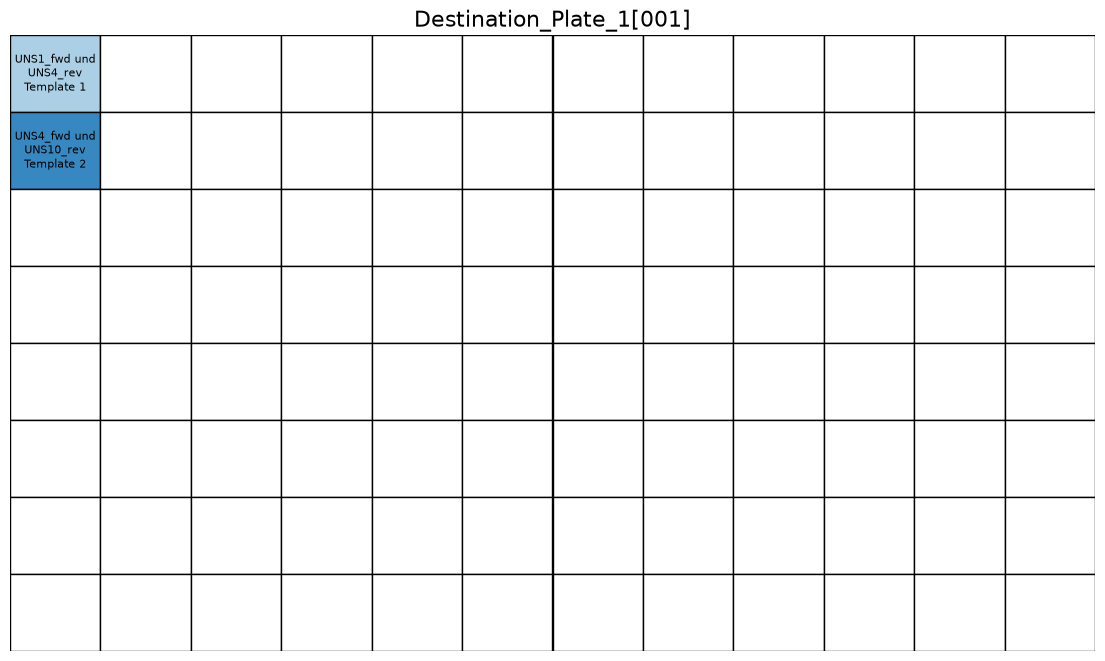

In [12]:
# Plot Destination Plate
assembly_manager.plot_destination_plate(save_path="results/Assembly_Plan.png", 
                                        highlight_column='Primer pairs',  
                                        max_lines=6,
                                        exclude_keywords=["water", "mastermix", "backbone"],
                                        color_palette=sns.color_palette("Blues", n_colors=2),
                                        cmap = "tab19",)

# Display the saved image
from IPython.display import Image
Image("results/Assembly_Plan.png")

<div><progress max="6" value="6"></progress> 100.00% [6/6 00:01&lt;00:00]</div>

09:47:27 INFO assembly_designer.manager.manager: Workflow simulation GIF written to results\Workflow_simulation.gif


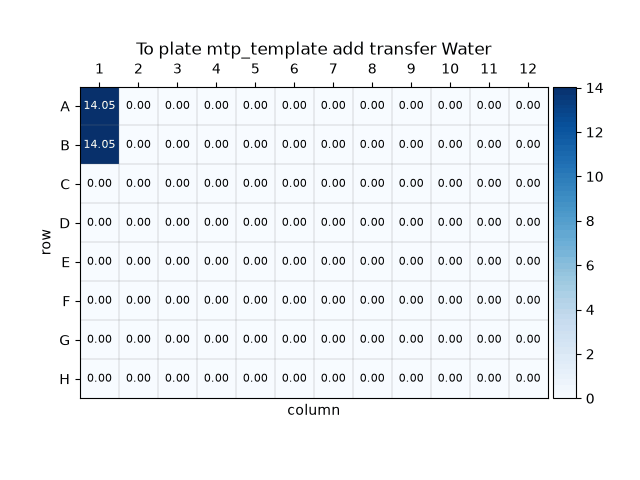

In [13]:
##### Check that the "# Initialize Workflow" cell is correctly set up before running the simulation, as it defines the workflow steps that will be executed.
##### Improper setup can lead to errors or an inaccurate simulation.
##### Ensure that the steps in the workflow match the operations you intend to simulate, and that the source and destination plates are correctly specified.

# Simulate the complete liquid handling process
assembly_manager.simulate_liquid_handling(fps=0.5, delay_frames=1)

<div><progress max="4" value="4"></progress> 100.00% [4/4 00:00&lt;00:00]</div>

09:47:28 INFO assembly_designer.mtp_manager.mtp_manager: Plate history GIF written to results\mtp_source[001].gif


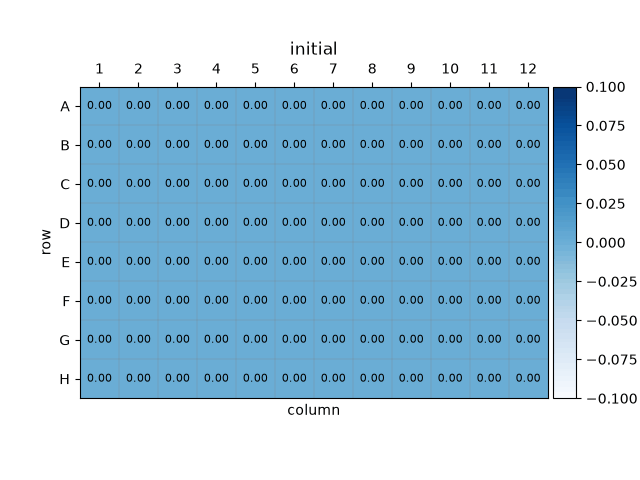

In [14]:
# Simulate plate history for the "mtp_source" plate (Primermix preparation)
mtp_manager.simulate_plate_history(mtp_manager.get_mtp("mtp_source"), fps=0.5, delay_frames=1)

<div><progress max="5" value="5"></progress> 100.00% [5/5 00:00&lt;00:00]</div>

09:47:29 INFO assembly_designer.mtp_manager.mtp_manager: Plate history GIF written to results\Destination_Plate_1[001].gif


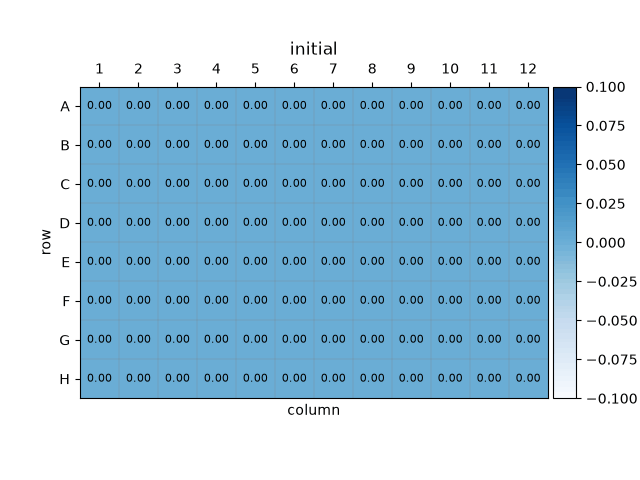

In [15]:
# Simulate plate history for the "mtp_destination" plate (final reaction assembly)
mtp_manager.simulate_plate_history(mtp_manager.get_mtp("mtp_destination"),fps=0.5, delay_frames=1)

In [16]:
mastermix_number_reaction=len(assembly_manager.df_volumes.groupby("Plate").get_group("mtp_template"))
mastermix_number_reaction

2

In [17]:
volume_per_reaction=20.0

In [18]:
df = calculate_dreamtaq_mastermix_components(
    volume_per_reaction=volume_per_reaction,
    dmso_fraction=0.05,
    mastermix_volume=mastermix_number_reaction*volume_per_reaction,
    primer_stock_um=10
)

df

,Component,Per Reaction (µL),Total Volume (µL)
0,DreamTaq PCR Master Mix (2X),10.0,20.0
1,Primer Fwd,1.0,2.0
2,Primer Rev,1.0,2.0
3,Template DNA,1.0,2.0
4,DMSO,1.0,2.0
5,Nuclease-free water,6.0,12.0
